<div align="center">
<h1>🔐 KRİPTOQRAFİYA KURSU</h1>
<h2>Məşğələ 14</h2>
<h2>SHA-3 (Keccak) və Süngər Quruluşu</h2>
<h3 style="color: #8B4513;">NIST SHA-3 yarışması, Keccak-f permutasiyası, XOF</h3>
<br>
<h3>Məşğələ vaxtı: 2 saat</h3>
<br>
<p><em>Hazırlanma tarixi: 2024</em></p>
</div>

## 📑 Mündəricat

1. [Məşğələnin məqsədləri](#məşğələnin-məqsədləri)
2. [Lazım olan kitabxanalar](#lazım-olan-kitabxanalar)
3. [Hazırlıq (15 dəq)](#hazırlıq-15-dəq)
4. [Xatırlatma: NIST SHA-3 yarışması (10 dəq)](#xatırlatma-nist-sha-3-yarışması-10-dəq)
5. [Süngər (Sponge) quruluşu (20 dəq)](#süngər-sponge-quruluşu-20-dəq)
6. [Python-da SHA-3 istifadəsi (15 dəq)](#python-da-sha-3-istifadəsi-15-dəq)
7. [Keccak-f permutasiyası (20 dəq)](#keccak-f-permutasiyası-20-dəq)
8. [SHA-3 və SHA-2 müqayisəsi (15 dəq)](#sha-3-və-sha-2-müqayisəsi-15-dəq)
9. [Praktik tətbiqlər (10 dəq)](#praktik-tətbiqlər-10-dəq)
10. [İnteqrasiya edilmiş tətbiq (15 dəq)](#inteqrasiya-edilmiş-tətbiq-15-dəq)
11. [Ev tapşırığı](#ev-tapşırığı)
12. [Yekun və müzakirə sualları](#yekun-və-müzakirə-sualları)
13. [Əlavə resurslar](#əlavə-resurslar)

## 🎯 Məşğələnin məqsədləri

Bu məşğələni bitirdikdən sonra siz:

✅ NIST SHA-3 yarışmasının tarixini və Keccak alqoritminin seçilmə səbəblərini izah edə biləcəksiniz  
✅ Süngər (sponge) quruluşunun iş prinsipini, udma və sıxma mərhələlərini başa düşəcəksiniz  
✅ Keccak-f permutasiyasının 5 qatını (theta, rho, pi, chi, iota) izah edə biləcəksiniz  
✅ SHA-3-ün müxtəlif variantlarını (SHA3-224, SHA3-256, SHA3-384, SHA3-512) Python-da istifadə edə biləcəksiniz  
✅ SHAKE128/256 XOF funksiyalarını başa düşəcəksiniz  
✅ SHA-3-ün SHA-2-dən üstünlüklərini müqayisə edə biləcəksiniz

## 📚 Lazım olan kitabxanalar

| Kitabxana | Quraşdırma | İstifadə sahəsi |
|-----------|------------|-----------------|
| hashlib | Python standart kitabxanası | SHA-3, SHAKE128, SHAKE256 |
| time | Python standart kitabxanası | Performans ölçmə |
| matplotlib | `!pip install matplotlib` | Qrafiklər çəkmək üçün |
| numpy | `!pip install numpy` | Rəqəmsal hesablamalar |

> 💡 **Qeyd:** Python 3.6+ versiyalarında hashlib SHA-3-ü dəstəkləyir. Köhnə versiyalarda `pysha3` paketi quraşdırmaq lazım ola bilər.

In [1]:
# Lazımi kitabxanaların quraşdırılması

!pip install matplotlib numpy --quiet

print("✅ Kitabxanalar quraşdırıldı")

✅ Kitabxanalar quraşdırıldı


## 🔧 Hazırlıq (15 dəq)

### 3.1 Python mühitinin yoxlanılması

Aşağıdakı kodu işə salaraq lazımi modulların yükləndiyini yoxlayın:

In [2]:
import sys
import hashlib
import time
import os
import math
import random
from collections import Counter

# hashlib-də SHA-3 dəstəyini yoxla
print("=" * 70)
print("🔍 SHA-3 DƏSTƏYİ YOXLANIR")
print("=" * 70)

try:
    # SHA3-256 testi
    test_hash = hashlib.sha3_256(b"test").hexdigest()
    print("✅ SHA3-256 dəstəklənir")

    # SHAKE128 testi
    test_shake = hashlib.shake_128(b"test").hexdigest(16)
    print("✅ SHAKE128 dəstəklənir")

    SHA3_AVAILABLE = True
except AttributeError:
    print("❌ SHA-3 dəstəklənmir!")
    print("   Python 3.6+ yüksəldin və ya 'pip install pysha3' edin")
    SHA3_AVAILABLE = False

# Əlavə kitabxanalar
try:
    import numpy as np
    import matplotlib.pyplot as plt
    print("\n✅ numpy və matplotlib yüklü - qrafiklər çəkilə bilər")
    PLT_AVAILABLE = True
except ImportError:
    print("\n⚠️ Bəzi kitabxanalar yoxdur")
    PLT_AVAILABLE = False

print(f"\n🐍 Python versiyası: {sys.version}")

🔍 SHA-3 DƏSTƏYİ YOXLANIR
✅ SHA3-256 dəstəklənir
✅ SHAKE128 dəstəklənir

✅ numpy və matplotlib yüklü - qrafiklər çəkilə bilər

🐍 Python versiyası: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


### 3.2 İşçi qovluğun yaradılması

In [3]:
from pathlib import Path
import os

# İşçi qovluğu yaradaq (təkrar işə salanda qovluqları iç-içə yaratmamaq üçün)
current_dir = Path.cwd().resolve()
if current_dir.parts[-2:] == ("crypto_workshop", "lecture15"):
    workspace = current_dir
else:
    workspace = current_dir / "crypto_workshop" / "lecture15"

workspace.mkdir(parents=True, exist_ok=True)
os.chdir(workspace)

print(f"📁 İşçi qovluq: {os.getcwd()}")
print(f"📂 Qovluğun məzmunu: {os.listdir('.')}")

📁 İşçi qovluq: /content/crypto_workshop/lecture15
📂 Qovluğun məzmunu: []


## 📖 Xatırlatma: NIST SHA-3 yarışması (10 dəq)

<div style="background-color: #fff3e0; padding: 15px; border-radius: 10px; border-left: 5px solid #ff9800;">
<h4>📜 NIST SHA-3 yarışması (2007-2012)</h4>
<p>2007-ci ildə NIST yeni heş funksiyası standartı üçün açıq beynəlxalq müsabiqə elan etdi. Səbəblər:</p>
<ul>
    <li>SHA-1-ə qarşı toqquşma hücumlarının güclənməsi</li>
    <li>SHA-2-nin Merkl-Damqord quruluşlu olması (uzunluq genişləndirmə hücumu)</li>
    <li>Uzunmüddətli təhlükəsizlik üçün alternativ quruluşa ehtiyac</li>
</ul>
<p>2012-ci ildə <b>Keccak</b> alqoritmi qalib elan edildi; SHA-3 isə FIPS 202 kimi 2015-ci ildə standartlaşdırıldı.</p>
</div>

<div style="background-color: #f0f8ff; padding: 15px; border-radius: 10px; border-left: 5px solid #4682b4; margin-top: 10px;">
<h4>🔑 Keccak-ın seçilmə səbəbləri</h4>
<ul>
    <li><b>İnnovativ dizayn:</b> Süngər (sponge) quruluşu</li>
    <li><b>Yüksək təhlükəsizlik:</b> Kriptoanalizə qarşı dayanıqlılıq</li>
    <li><b>Çeviklik:</b> Dəyişkən çıxış uzunluqları (XOF) dəstəyi</li>
    <li><b>Yaxşı performans:</b> Həm proqram, həm də aparatda səmərəli</li>
</ul>
</div>

## 🧽 Süngər (Sponge) quruluşu (20 dəq)

<div style="background-color: #f0f8ff; padding: 15px; border-radius: 10px; border-left: 5px solid #4682b4;">
<h4>🧽 Süngər quruluşu</h4>
<p>Süngər quruluşu iki mərhələdən ibarətdir:</p>
<ol>
    <li><b>Udma (absorb):</b> Giriş mesajı daxili vəziyyətə udulur</li>
    <li><b>Sıxma (squeeze):</b> Daxili vəziyyətdən çıxış sıxılır</li>
</ol>

<p><b>Parametrlər:</b></p>
<ul>
    <li>$b = r + c$ — daxili vəziyyətin ümumi ölçüsü</li>
    <li>$r$ — bit sürəti (rate) — udma/sıxma sürəti</li>
    <li>$c$ — təhlükəsizlik (capacity) — gizli qalan hissə</li>
</ul>

<p><b>SHA-3 parametrləri:</b></p>
<table>
<tr><th>Alqoritm</th><th>Çıxış (bit)</th><th>rate r</th><th>capacity c</th><th>Təhlükəsizlik</th></tr>
<tr><td>SHA3-224</td><td>224</td><td>1152 bit (144 bayt)</td><td>448 bit</td><td>112-bit</td></tr>
<tr><td>SHA3-256</td><td>256</td><td>1088 bit (136 bayt)</td><td>512 bit</td><td>128-bit</td></tr>
<tr><td>SHA3-384</td><td>384</td><td>832 bit (104 bayt)</td><td>768 bit</td><td>192-bit</td></tr>
<tr><td>SHA3-512</td><td>512</td><td>576 bit (72 bayt)</td><td>1024 bit</td><td>256-bit</td></tr>
<tr><td>SHAKE128</td><td>ixtiyari</td><td>1344 bit (168 bayt)</td><td>256 bit</td><td>128-bit</td></tr>
<tr><td>SHAKE256</td><td>ixtiyari</td><td>1088 bit (136 bayt)</td><td>512 bit</td><td>256-bit</td></tr>
</table>
</div>

In [4]:
class SpongeConstruction:
    """
    Süngər quruluşunun sadə simulyasiyası (təhsil məqsədli).

    Qeyd: Bu sinif FIPS 202 SHA-3 implementasiyası deyil.
    Məqsəd absorb -> permutation -> squeeze axınını göstərməkdir.
    """

    def __init__(self, rate=16, capacity=16, rounds=24):
        """
        rate: udma/sıxma sürəti (bayt)
        capacity: daxili vəziyyətin gizli hissəsi (bayt)
        """
        if rate <= 0 or capacity <= 0:
            raise ValueError("rate və capacity müsbət olmalıdır")

        self.rate = rate
        self.capacity = capacity
        self.state = [0] * (rate + capacity)
        self.rounds = rounds

    def _permutation(self):
        """
        Sadə permutasiya simulyasiyası (əsl Keccak-f deyil!)
        """
        for _ in range(self.rounds):
            new_state = []
            for i in range(len(self.state)):
                val = self.state[i] ^ (self.state[(i + 1) % len(self.state)] << 3)
                val = ((val << 1) | (val >> 7)) & 0xFF
                new_state.append(val)
            self.state = new_state

    def _pad10star1(self, data):
        """
        Byte-səviyyəli pad10*1 doldurması.
        Çıxış uzunluğu həmişə rate-ə tam bölünür.
        """
        if not isinstance(data, (bytes, bytearray)):
            raise TypeError("data bytes və ya bytearray olmalıdır")

        remainder = len(data) % self.rate
        pad_len = self.rate - remainder if remainder != 0 else self.rate

        if pad_len == 1:
            return bytes(data) + b'\x81'

        return bytes(data) + b'\x80' + b'\x00' * (pad_len - 2) + b'\x01'

    def absorb(self, data):
        """
        Udma mərhələsi
        """
        padded = self._pad10star1(data)

        for i in range(0, len(padded), self.rate):
            block = padded[i:i + self.rate]

            for j, byte in enumerate(block):
                self.state[j] ^= byte

            self._permutation()

    def squeeze(self, output_length):
        """
        Sıxma mərhələsi
        """
        if output_length < 0:
            raise ValueError("output_length mənfi ola bilməz")

        output = bytearray()
        while len(output) < output_length:
            for i in range(self.rate):
                if len(output) >= output_length:
                    break
                output.append(self.state[i])

            if len(output) < output_length:
                self._permutation()

        return bytes(output)

    def hash(self, data, output_length):
        """
        Tam heşləmə prosesi
        """
        self.state = [0] * len(self.state)
        self.absorb(data)
        return self.squeeze(output_length)


# Test
print("\n" + "=" * 70)
print("🧽 SÜNGƏR QURULUŞU SİMULYASİYASI")
print("=" * 70)

sponge = SpongeConstruction(rate=8, capacity=8, rounds=4)
data = b"Salam, dunya!"
hash_value = sponge.hash(data, 16)

print(f"📨 Giriş: {data}")
print(f"🔹 Çıxış (16 bayt): {hash_value.hex()}")



🧽 SÜNGƏR QURULUŞU SİMULYASİYASI
📨 Giriş: b'Salam, dunya!'
🔹 Çıxış (16 bayt): 8f1eff2f3e3c22743fafbf2e3e196e2f


### ✍️ Çalışma 1: Süngər quruluşu (1.5 bal)

Aşağıdakı tapşırıqları yerinə yetirin:

1. **Komponentlər:** Süngər quruluşunun əsas komponentlərini sadalayın.

2. **Parametrlər:** $r$ və $c$ parametrləri nəyi ifadə edir?

3. **Hesablama:** SHA3-256 üçün $r=1088$, $c=512$ verilib. Daxili vəziyyətin ümumi ölçüsü nədir?

4. **Mərhələlər:** Udma və sıxma mərhələlərini izah edin.

In [5]:
# Çalışma 1 - Cavablar

print("📝 ÇALIŞMA 1 CAVABLARI")
print("=" * 80)

# 1. Komponentlər
print("\n1. KOMPONENTLƏR:")
print("""
   Süngər quruluşunun əsas komponentləri:
   • Daxili vəziyyət (state) - b = r + c bit
   • f permutasiya funksiyası
   • Doldurma (padding) funksiyası
   • Udma (absorb) mərhələsi
   • Sıxma (squeeze) mərhələsi
""")

# 2. Parametrlər
print("\n2. PARAMETRLƏR:")
print("""
   r (rate): bit sürəti - hər raundda udulan/sıxılan bit sayı
   c (capacity): təhlükəsizlik parametri - gizli qalan hissə

   • r böyükdürsə → daha sürətli, lakin daha az təhlükəsiz
   • c böyükdürsə → daha yavaş, lakin daha təhlükəsiz
""")

# 3. Hesablama
print("\n3. HESABLAMA:")
r = 1088
c = 512
b = r + c
print(f"   SHA3-256 üçün: r = {r} bit, c = {c} bit")
print(f"   Daxili vəziyyət ölçüsü: b = r + c = {r} + {c} = {b} bit = {b//8} bayt")

# 4. Mərhələlər
print("\n4. MƏRHƏLƏLƏR:")
print("""
   Udma (absorb):
   • Giriş mesajı bloklara bölünür
   • Hər blok vəziyyətin r hissəsi ilə XOR edilir
   • f permutasiyası tətbiq edilir

   Sıxma (squeeze):
   • Vəziyyətin r hissəsi çıxışa əlavə edilir
   • Daha çox çıxış tələb olunarsa, f tətbiq edilir
   • İstənilən uzunluqda çıxış almaq mümkündür (XOF)
""")

📝 ÇALIŞMA 1 CAVABLARI

1. KOMPONENTLƏR:

   Süngər quruluşunun əsas komponentləri:
   • Daxili vəziyyət (state) - b = r + c bit
   • f permutasiya funksiyası
   • Doldurma (padding) funksiyası
   • Udma (absorb) mərhələsi
   • Sıxma (squeeze) mərhələsi


2. PARAMETRLƏR:

   r (rate): bit sürəti - hər raundda udulan/sıxılan bit sayı
   c (capacity): təhlükəsizlik parametri - gizli qalan hissə

   • r böyükdürsə → daha sürətli, lakin daha az təhlükəsiz
   • c böyükdürsə → daha yavaş, lakin daha təhlükəsiz


3. HESABLAMA:
   SHA3-256 üçün: r = 1088 bit, c = 512 bit
   Daxili vəziyyət ölçüsü: b = r + c = 1088 + 512 = 1600 bit = 200 bayt

4. MƏRHƏLƏLƏR:

   Udma (absorb):
   • Giriş mesajı bloklara bölünür
   • Hər blok vəziyyətin r hissəsi ilə XOR edilir
   • f permutasiyası tətbiq edilir

   Sıxma (squeeze):
   • Vəziyyətin r hissəsi çıxışa əlavə edilir
   • Daha çox çıxış tələb olunarsa, f tətbiq edilir
   • İstənilən uzunluqda çıxış almaq mümkündür (XOF)



## 🐍 Python-da SHA-3 istifadəsi (15 dəq)

In [6]:
def sha3_demo():
    """
    SHA-3 variantlarının nümayişi
    """
    if not SHA3_AVAILABLE:
        print("SHA-3 dəstəklənmir!")
        return

    print("\n" + "=" * 70)
    print("🔐 SHA-3 VARİANTLARI")
    print("=" * 70)

    message = b"Kriptoqrafiya kursu 2024"
    print(f"📨 Mesaj: {message}\n")

    # SHA3-224
    h224 = hashlib.sha3_224(message).hexdigest()
    print(f"🔹 SHA3-224 (224-bit): {h224}")
    print(f"   Uzunluq: {len(h224)} hex simvol = {len(h224)*4} bit\n")

    # SHA3-256
    h256 = hashlib.sha3_256(message).hexdigest()
    print(f"🔹 SHA3-256 (256-bit): {h256}")
    print(f"   Uzunluq: {len(h256)} hex simvol = {len(h256)*4} bit\n")

    # SHA3-384
    h384 = hashlib.sha3_384(message).hexdigest()
    print(f"🔹 SHA3-384 (384-bit): {h384[:64]}...")
    print(f"   Uzunluq: {len(h384)} hex simvol = {len(h384)*4} bit\n")

    # SHA3-512
    h512 = hashlib.sha3_512(message).hexdigest()
    print(f"🔹 SHA3-512 (512-bit): {h512[:64]}...")
    print(f"   Uzunluq: {len(h512)} hex simvol = {len(h512)*4} bit")

if SHA3_AVAILABLE:
    sha3_demo()


🔐 SHA-3 VARİANTLARI
📨 Mesaj: b'Kriptoqrafiya kursu 2024'

🔹 SHA3-224 (224-bit): d6896f0903f87bba8b902171d9467da6e20b288ecc7c448e64ff341e
   Uzunluq: 56 hex simvol = 224 bit

🔹 SHA3-256 (256-bit): 065821b6fd85527bbaa8ce6e3b7af27ae9f3021884c1d9904cfe5e6d436ebdff
   Uzunluq: 64 hex simvol = 256 bit

🔹 SHA3-384 (384-bit): 9cb6f8f732a8ed05526b1420534d13a567cf7b0f7b600be29ec539f1968f4940...
   Uzunluq: 96 hex simvol = 384 bit

🔹 SHA3-512 (512-bit): a7c895389d5862aeb220998e32d39af3155e7a73addd042670f0e45097c0499f...
   Uzunluq: 128 hex simvol = 512 bit


### 6.1 SHAKE XOF (eXtendable Output Function) funksiyaları

In [7]:
def shake_demo():
    """
    SHAKE XOF funksiyalarının nümayişi
    """
    if not SHA3_AVAILABLE:
        return

    print("\n" + "-" * 70)
    print("🔄 SHAKE XOF (EXTENDABLE OUTPUT FUNCTION)")
    print("-" * 70)

    message = b"Kriptoqrafiya kursu"
    print(f"📨 Mesaj: {message}\n")

    # Eyni SHAKE obyektindən müxtəlif uzunluqlarda çıxış almaq olar
    shake128 = hashlib.shake_128(message)
    out32 = shake128.hexdigest(32)
    out48 = shake128.hexdigest(48)

    print(f"📊 SHAKE128 (32 bayt): {out32}")
    print(f"📊 SHAKE128 (48 bayt): {out48}")
    print(f"   32 baytlıq çıxış 48 baytlığın prefiksidir: {out48.startswith(out32)}\n")

    print("📊 SHAKE256 müxtəlif uzunluqlarda:")
    shake256 = hashlib.shake_256(message)
    for length in (16, 32, 64):
        print(f"   {length:2d} bayt: {shake256.hexdigest(length)}")

    print("\n💡 Qeyd: hashlib-də SHAKE obyektindən eyni mesaj üçün bir neçə dəfə")
    print("   fərqli uzunluqda çıxış almaq olar; daha uzun çıxış daha qısa")
    print("   çıxışın prefiksi olur.")


if SHA3_AVAILABLE:
    shake_demo()



----------------------------------------------------------------------
🔄 SHAKE XOF (EXTENDABLE OUTPUT FUNCTION)
----------------------------------------------------------------------
📨 Mesaj: b'Kriptoqrafiya kursu'

📊 SHAKE128 (32 bayt): a1e5865b061562773b8539011c31a69f55fed6395b2bbd2d6b8da562d4edf4b0
📊 SHAKE128 (48 bayt): a1e5865b061562773b8539011c31a69f55fed6395b2bbd2d6b8da562d4edf4b0554ad8a50912cf37fb521487887be66e
   32 baytlıq çıxış 48 baytlığın prefiksidir: True

📊 SHAKE256 müxtəlif uzunluqlarda:
   16 bayt: 333552b65262c35bb5d2fed519ad2fcb
   32 bayt: 333552b65262c35bb5d2fed519ad2fcb6d29648e878ffb5b6b7ca9bd3009e4e4
   64 bayt: 333552b65262c35bb5d2fed519ad2fcb6d29648e878ffb5b6b7ca9bd3009e4e4323ec93d064c6da2cac5932cdf768a4e6447fde693fa960e05b3700a2b25b0ff

💡 Qeyd: hashlib-də SHAKE obyektindən eyni mesaj üçün bir neçə dəfə
   fərqli uzunluqda çıxış almaq olar; daha uzun çıxış daha qısa
   çıxışın prefiksi olur.


### ✍️ Çalışma 2: SHA-3 istifadəsi (1 bal)

Aşağıdakı tapşırıqları yerinə yetirin:

1. **Şəxsi heş:** Öz adınızın SHA3-256 və SHA3-512 heşlərini hesablayın.

2. **SHAKE128:** SHAKE128 istifadə edərək 48 baytlıq çıxış yaradın.

3. **Müqayisə:** SHA-256 və SHA3-256-nın çıxış uzunluqlarını müqayisə edin.

4. **XOF anlayışı:** Niyə SHAKE128 "genişləndirilə bilən çıxış funksiyası" (XOF) adlanır?

In [8]:
# Çalışma 2 - Cavablar

print("📝 ÇALIŞMA 2 CAVABLARI")
print("=" * 80)

if SHA3_AVAILABLE:
    # 1. Şəxsi heş
    print("\n1. ŞƏXSİ HEŞ (SHA-3):")
    my_name = "Səməd Vəkilov"  # Öz adınızla əvəz edin
    name_bytes = my_name.encode()
    h3_256 = hashlib.sha3_256(name_bytes).hexdigest()
    h3_512 = hashlib.sha3_512(name_bytes).hexdigest()
    print(f"   Ad: {my_name}")
    print(f"   SHA3-256: {h3_256}")
    print(f"   SHA3-512: {h3_512[:64]}...")

    # 2. SHAKE128 48 bayt
    print("\n2. SHAKE128 48 BAYT:")
    shake = hashlib.shake_128(b"Test mesaji")
    out48 = shake.hexdigest(48)
    print(f"   {out48}")

# 3. Müqayisə
print("\n3. ÇIXIŞ UZUNLUQLARI:")
print("   SHA-256:   256-bit (32 bayt)")
print("   SHA3-256:  256-bit (32 bayt)")
print("   Çıxış uzunluqları eynidir, lakin daxili quruluş fərqlidir.")

# 4. XOF anlayışı
print("\n4. XOF ANLAYIŞI:")
print("""
   SHAKE (Secure Hash Algorithm KECCAK) genişləndirilə bilən çıxış funksiyasıdır, çünki:
   • İstənilən uzunluqda çıxış generasiya etmək olar
   • Süngər quruluşu sayəsində sıxma mərhələsi sonsuz davam edə bilər
   • Sabit uzunluqlu heşlərdən fərqli olaraq, çıxış uzunluğu əvvəlcədən təyin olunmur
   • PRNG (Pseudorandom Number Generator) kimi istifadə oluna bilər
""")

📝 ÇALIŞMA 2 CAVABLARI

1. ŞƏXSİ HEŞ (SHA-3):
   Ad: Səməd Vəkilov
   SHA3-256: c78d81824c06faa283496861adf2e46f267f87af82a037fcda768fd3af567e98
   SHA3-512: a9cee0e4600a4bfa72324417c04b7bd519b1bca7224b689cd9238eebb5ebe618...

2. SHAKE128 48 BAYT:
   253fc58a45d388b01b45d87c7e4ebf13c32b114912671b631ce2737bf2f785142ebad91cf633fdae89d4d912625c5adc

3. ÇIXIŞ UZUNLUQLARI:
   SHA-256:   256-bit (32 bayt)
   SHA3-256:  256-bit (32 bayt)
   Çıxış uzunluqları eynidir, lakin daxili quruluş fərqlidir.

4. XOF ANLAYIŞI:

   SHAKE (Secure Hash Algorithm KECCAK) genişləndirilə bilən çıxış funksiyasıdır, çünki:
   • İstənilən uzunluqda çıxış generasiya etmək olar
   • Süngər quruluşu sayəsində sıxma mərhələsi sonsuz davam edə bilər
   • Sabit uzunluqlu heşlərdən fərqli olaraq, çıxış uzunluğu əvvəlcədən təyin olunmur
   • PRNG (Pseudorandom Number Generator) kimi istifadə oluna bilər



## 🔄 Keccak-f permutasiyası (20 dəq)

<div style="background-color: #f0f8ff; padding: 15px; border-radius: 10px; border-left: 5px solid #4682b4;">
<h4>🔄 Keccak-f permutasiyası</h4>
<p>Keccak-f permutasiyası 1600-bit daxili vəziyyət üzərində 24 raundda tətbiq olunur. Vəziyyət 5×5×64 bit ölçülü üçölçülü matris şəklində təşkil olunub:</p>

<p style="text-align: center; font-size: 1.2em;">$$\text{state}[x][y][z]$$</p>

<p>burada $x, y \in \{0,...,4\}$, $z \in \{0,...,63\}$.</p>
</div>

In [9]:
def keccak_f_layers_demo():
    """
    Keccak-f permutasiyasının 5 qatının izahı
    """
    print("\n" + "-" * 70)
    print("🔄 KECCAK-F PERMUTASİYASININ 5 QATI")
    print("-" * 70)

    print("""
    1. THETA (θ) - Sütunlararası diffuziya
       • Hər bir biti eyni sütundakı digər bitlərə yayır
       • Qonşu sütunlara da təsir edir
       • Formula: C[x] = XOR_y state[x][y]
                 D[x] = C[x-1] ⊕ ROT(C[x+1], 1)
                 state[x][y] ⊕= D[x]

    2. RHO (ρ) - Sözlər daxilində bit sürüşdürmə
       • Hər sözü müxtəlif miqdarda fırladır
       • 25 söz üçün 25 fərqli fırlatma miqdarı
       • Formula: state[x][y] = ROT(state[x][y], r[x][y])

    3. PI (π) - Sözlərin transpozisiyası
       • Sözlərin mövqelərini dəyişdirir
       • Formula: state[x][y] = state[x + 3y mod 5][x]

    4. CHI (χ) - Qeyri-xətti əvəzetmə (yeganə qeyri-xətti qat)
       • Hər sözü qonşu sözlərin funksiyası kimi yeniləyir
       • Formula: state[x][y] ⊕= (¬state[x+1][y]) ∧ state[x+2][y]

    5. IOTA (ι) - Raund sabitinin əlavə edilməsi
       • Hər raundda fərqli sabit əlavə edir
       • Formula: state[0][0] ⊕= RC[i]
    """)

keccak_f_layers_demo()


----------------------------------------------------------------------
🔄 KECCAK-F PERMUTASİYASININ 5 QATI
----------------------------------------------------------------------

    1. THETA (θ) - Sütunlararası diffuziya
       • Hər bir biti eyni sütundakı digər bitlərə yayır
       • Qonşu sütunlara da təsir edir
       • Formula: C[x] = XOR_y state[x][y]
                 D[x] = C[x-1] ⊕ ROT(C[x+1], 1)
                 state[x][y] ⊕= D[x]

    2. RHO (ρ) - Sözlər daxilində bit sürüşdürmə
       • Hər sözü müxtəlif miqdarda fırladır
       • 25 söz üçün 25 fərqli fırlatma miqdarı
       • Formula: state[x][y] = ROT(state[x][y], r[x][y])

    3. PI (π) - Sözlərin transpozisiyası
       • Sözlərin mövqelərini dəyişdirir
       • Formula: state[x][y] = state[x + 3y mod 5][x]

    4. CHI (χ) - Qeyri-xətti əvəzetmə (yeganə qeyri-xətti qat)
       • Hər sözü qonşu sözlərin funksiyası kimi yeniləyir
       • Formula: state[x][y] ⊕= (¬state[x+1][y]) ∧ state[x+2][y]

    5. IOTA (ι) - Raund s

In [10]:
class SimplifiedKeccakF:
    """
    Keccak-f[1600] qatlarının tədris məqsədli demonstrasiyası.

    Qeyd: Bu sinif tam SHA-3 hash funksiyası deyil; yalnız 5×5 ölçülü
    64-bit lane-lər üzərində Keccak-f permutasiyasının qatlarını göstərir.
    """

    MASK64 = (1 << 64) - 1
    RHO_OFFSETS = [
        0, 1, 62, 28, 27,
        36, 44, 6, 55, 20,
        3, 10, 43, 25, 39,
        41, 45, 15, 21, 8,
        18, 2, 61, 56, 14,
    ]
    ROUND_CONSTANTS = [
        0x0000000000000001, 0x0000000000008082,
        0x800000000000808A, 0x8000000080008000,
        0x000000000000808B, 0x0000000080000001,
        0x8000000080008081, 0x8000000000008009,
        0x000000000000008A, 0x0000000000000088,
        0x0000000080008009, 0x000000008000000A,
        0x000000008000808B, 0x800000000000008B,
        0x8000000000008089, 0x8000000000008003,
        0x8000000000008002, 0x8000000000000080,
        0x000000000000800A, 0x800000008000000A,
        0x8000000080008081, 0x8000000000008080,
        0x0000000080000001, 0x8000000080008008,
    ]

    def __init__(self, size=25):
        if size != 25:
            raise ValueError("Keccak-f[1600] üçün 25 ədəd 64-bit lane tələb olunur")
        self.size = size
        self.state = [0] * size

    @classmethod
    def _rotl64(cls, value, shift):
        shift %= 64
        value &= cls.MASK64
        if shift == 0:
            return value
        return ((value << shift) | (value >> (64 - shift))) & cls.MASK64

    def theta(self):
        """Theta qatı"""
        c = [0] * 5
        for x in range(5):
            c[x] = (
                self.state[x]
                ^ self.state[x + 5]
                ^ self.state[x + 10]
                ^ self.state[x + 15]
                ^ self.state[x + 20]
            ) & self.MASK64

        d = [0] * 5
        for x in range(5):
            d[x] = c[(x - 1) % 5] ^ self._rotl64(c[(x + 1) % 5], 1)

        for x in range(5):
            for y in range(5):
                idx = x + 5 * y
                self.state[idx] = (self.state[idx] ^ d[x]) & self.MASK64

    def rho(self):
        """Rho qatı"""
        for idx, offset in enumerate(self.RHO_OFFSETS):
            self.state[idx] = self._rotl64(self.state[idx], offset)

    def pi(self):
        """Pi qatı"""
        new_state = [0] * self.size
        for x in range(5):
            for y in range(5):
                src = x + 5 * y
                dst = y + 5 * ((2 * x + 3 * y) % 5)
                new_state[dst] = self.state[src]
        self.state = new_state

    def chi(self):
        """Chi qatı"""
        new_state = self.state.copy()
        for y in range(5):
            row = [self.state[x + 5 * y] for x in range(5)]
            for x in range(5):
                new_state[x + 5 * y] = (
                    row[x] ^ ((~row[(x + 1) % 5] & self.MASK64) & row[(x + 2) % 5])
                ) & self.MASK64
        self.state = new_state

    def iota(self, round_idx):
        """Iota qatı"""
        self.state[0] = (self.state[0] ^ self.ROUND_CONSTANTS[round_idx]) & self.MASK64

    def round(self, round_idx):
        """Bir raund tətbiq et"""
        self.theta()
        self.rho()
        self.pi()
        self.chi()
        self.iota(round_idx)

    def permute(self, rounds=24):
        """Tam permutasiya"""
        if not 0 <= rounds <= len(self.ROUND_CONSTANTS):
            raise ValueError("rounds 0 ilə 24 arasında olmalıdır")
        for i in range(rounds):
            self.round(i)

    def print_state(self):
        """Vəziyyəti çap et"""
        for y in range(5):
            row = []
            for x in range(5):
                row.append(f"{self.state[x + 5 * y]:016x}")
            print(" ".join(row))


# Test
print("\n" + "-" * 70)
print("🔄 KECCAK-F[1600] QAT DEMOSU")
print("-" * 70)

keccak = SimplifiedKeccakF()
for i in range(25):
    keccak.state[i] = i + 1

print("📊 İlkin vəziyyət:")
keccak.print_state()

keccak.permute(rounds=2)

print("\n📊 2 raunddan sonra:")
keccak.print_state()



----------------------------------------------------------------------
🔄 KECCAK-F[1600] QAT DEMOSU
----------------------------------------------------------------------
📊 İlkin vəziyyət:
0000000000000001 0000000000000002 0000000000000003 0000000000000004 0000000000000005
0000000000000006 0000000000000007 0000000000000008 0000000000000009 000000000000000a
000000000000000b 000000000000000c 000000000000000d 000000000000000e 000000000000000f
0000000000000010 0000000000000011 0000000000000012 0000000000000013 0000000000000014
0000000000000015 0000000000000016 0000000000000017 0000000000000018 0000000000000019

📊 2 raunddan sonra:
f9a28fd0019fd032 15596288e6bc75a2 217cdd51263a81e6 0c1c9468efe6e0c6 f999a971ab957702
8ad70cf6f3d08ec7 42b484217916283a c930053f34e7d743 f061c44093fe3244 a120d9ff425742c6
c44b4d00fea1286c 02974db1b694602b e45866c0c36e4738 03e51a25f255baa5 257016e74b8d349a
1d3832958818db38 7bec0b5699e13d9f 18dc05fae65ce94d 63b11f4883c94eba 7cf600d0704c1142
a2010f9c95b334f4 af0d433a

### ✍️ Çalışma 3: Keccak-f qatları (1.5 bal)

Aşağıdakı tapşırıqları yerinə yetirin:

1. **Qatların funksiyaları:** Keccak-f permutasiyasının 5 qatının hər birinin funksiyasını izah edin.

2. **Qeyri-xəttilik:** Chi qatı niyə qeyri-xətti adlanır? Onun rolu nədir?

3. **Diffuziya:** Theta qatı diffuziyanı necə təmin edir?

4. **Raund sabitləri:** Iota qatı niyə lazımdır? Raund sabitləri olmasaydı nə olardı?

In [11]:
# Çalışma 3 - Cavablar

print("📝 ÇALIŞMA 3 CAVABLARI")
print("=" * 80)

# 1. Qatların funksiyaları
print("\n1. QATLARIN FUNKSİYALARI:")
print("""
   THETA (θ): Sütunlararası diffuziya - bitləri sütun daxilində yayır
   RHO (ρ): Sözlər daxilində fırlatma - hər sözü fərqli miqdarda döndərir
   PI (π): Sözlərin transpozisiyası - mövqeləri dəyişir
   CHI (χ): Qeyri-xətti əvəzetmə - yeganə qeyri-xətti qat
   IOTA (ι): Raund sabitinin əlavə edilməsi - hər raundda fərqli
""")

# 2. Qeyri-xəttilik
print("\n2. QEYRİ-XƏTTİLİK:")
print("""
   Chi qatı qeyri-xəttidir, çünki:
   • XOR xətti əməliyyatdır, lakin AND qeyri-xəttidir; Chi qatının qeyri-xəttiliyi (¬a) ∧ b terminindən gəlir
   • Bu qat olmadan bütün Keccak xətti olardı (asan sındırılar)
   • Kriptoanalizə qarşı əsas müdafiə mexanizmidir
""")

# 3. Diffuziya
print("\n3. DİFFUZİYA:")
print("""
   Theta diffuziyanı təmin edir:
   • Hər bir bit eyni sütundakı bitlərə təsir edir
   • Qonşu sütunlara da təsir edir (döndərmə ilə)
   • Bir bit dəyişikliyi bir neçə sütuna yayılır
""")

# 4. Raund sabitləri
print("\n4. RAUND SABİTLƏRİ:")
print("""
   Iota qatı vacibdir, çünki:
   • Fərqli raundları bir-birindən ayırır
   • Simmetriyanı qırır (eyni giriş müxtəlif raundlarda fərqli çıxış verir)
   • Raund sabitləri olmasaydı, bütün raundlar eyni olardı
   • Bu, zəif təhlükəsizliyə səbəb olardı
""")

📝 ÇALIŞMA 3 CAVABLARI

1. QATLARIN FUNKSİYALARI:

   THETA (θ): Sütunlararası diffuziya - bitləri sütun daxilində yayır
   RHO (ρ): Sözlər daxilində fırlatma - hər sözü fərqli miqdarda döndərir
   PI (π): Sözlərin transpozisiyası - mövqeləri dəyişir
   CHI (χ): Qeyri-xətti əvəzetmə - yeganə qeyri-xətti qat
   IOTA (ι): Raund sabitinin əlavə edilməsi - hər raundda fərqli


2. QEYRİ-XƏTTİLİK:

   Chi qatı qeyri-xəttidir, çünki:
   • XOR xətti əməliyyatdır, lakin AND qeyri-xəttidir; Chi qatının qeyri-xəttiliyi (¬a) ∧ b terminindən gəlir
   • Bu qat olmadan bütün Keccak xətti olardı (asan sındırılar)
   • Kriptoanalizə qarşı əsas müdafiə mexanizmidir


3. DİFFUZİYA:

   Theta diffuziyanı təmin edir:
   • Hər bir bit eyni sütundakı bitlərə təsir edir
   • Qonşu sütunlara da təsir edir (döndərmə ilə)
   • Bir bit dəyişikliyi bir neçə sütuna yayılır


4. RAUND SABİTLƏRİ:

   Iota qatı vacibdir, çünki:
   • Fərqli raundları bir-birindən ayırır
   • Simmetriyanı qırır (eyni giriş müxtəlif raund

## 📊 SHA-3 və SHA-2 müqayisəsi (15 dəq)

In [12]:
def sha2_vs_sha3_comparison():
    """
    SHA-2 və SHA-3 müqayisəsi
    """
    if not SHA3_AVAILABLE:
        return

    print("\n" + "-" * 70)
    print("📊 SHA-2 vs SHA-3 MÜQAYİSƏSİ")
    print("-" * 70)

    message = b"Kriptoqrafiya kursu"

    # SHA-2
    sha256 = hashlib.sha256(message).hexdigest()
    sha512 = hashlib.sha512(message).hexdigest()

    # SHA-3
    sha3_256 = hashlib.sha3_256(message).hexdigest()
    sha3_512 = hashlib.sha3_512(message).hexdigest()

    print(f"SHA-256:    {sha256[:64]}...")
    print(f"SHA3-256:   {sha3_256[:64]}...\n")
    print(f"SHA-512:    {sha512[:64]}...")
    print(f"SHA3-512:   {sha3_512[:64]}...\n")

    print("📌 ÜSTÜNLÜKLƏR:")
    print("  SHA-3:")
    print("    • Uzunluq genişləndirmə hücumlarına davamlı")
    print("    • XOF dəstəyi (SHAKE128/256)")
    print("    • Fərqli quruluş (süngər)")
    print("  SHA-2:")
    print("    • Daha geniş yayılmış")
    print("    • Bəzi platformalarda daha sürətli")

if SHA3_AVAILABLE:
    sha2_vs_sha3_comparison()


----------------------------------------------------------------------
📊 SHA-2 vs SHA-3 MÜQAYİSƏSİ
----------------------------------------------------------------------
SHA-256:    3805f9006ca8924f22381255b5a18a33e72f10b6fc520a95010f3fcfa7e56691...
SHA3-256:   765b3ba6113faa4dba41faa49d25fe1b75aba8feacd9bbe9832c8205d2946733...

SHA-512:    50a1feed69f376db42e4ac77eb2699888ff111d503d63684bca4bbfb0ccf8df3...
SHA3-512:   3fb9efcf3505972097f9d56d661d4d99166c337c652406636b1529ebf60246da...

📌 ÜSTÜNLÜKLƏR:
  SHA-3:
    • Uzunluq genişləndirmə hücumlarına davamlı
    • XOF dəstəyi (SHAKE128/256)
    • Fərqli quruluş (süngər)
  SHA-2:
    • Daha geniş yayılmış
    • Bəzi platformalarda daha sürətli



----------------------------------------------------------------------
⚡ PERFORMANS MÜQAYİSƏSİ
----------------------------------------------------------------------
Ölçü       SHA-256         SHA-512         SHA3-256        SHA3-512       
----------------------------------------------------------------------
   1 KB     0.0032 ms     0.0025 ms     0.0038 ms     0.0065 ms
  10 KB     0.0255 ms     0.0200 ms     0.0310 ms     0.0571 ms
 100 KB     0.2515 ms     0.1667 ms     0.3063 ms     0.5704 ms
1024 KB     2.8983 ms     1.7120 ms     3.3476 ms     5.9016 ms


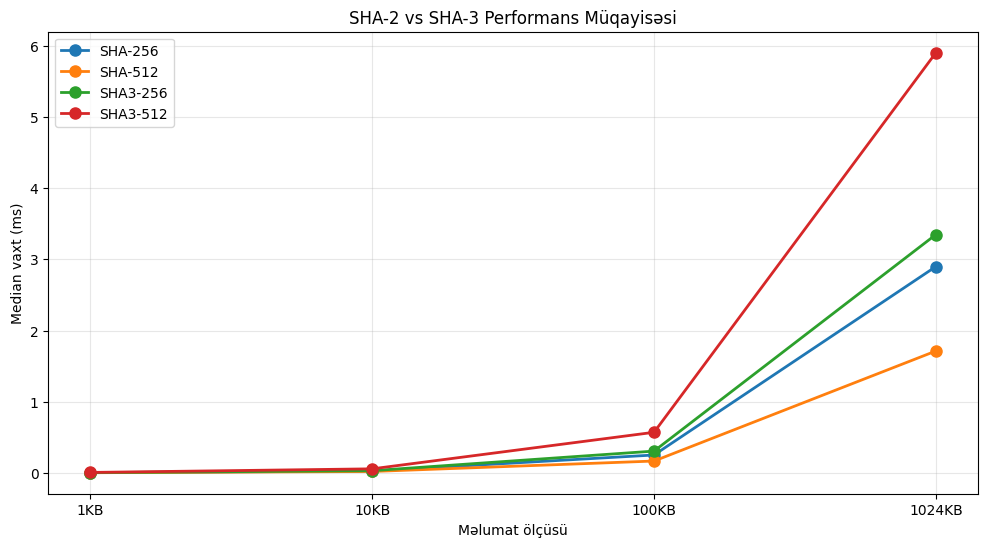

In [13]:
def performance_comparison():
    """
    SHA-2 və SHA-3 performans müqayisəsi
    """
    if not SHA3_AVAILABLE:
        return

    def benchmark(hash_constructor, data, repeats):
        measurements = []
        for _ in range(repeats):
            start = time.perf_counter()
            hash_constructor(data).digest()
            measurements.append((time.perf_counter() - start) * 1000)
        measurements.sort()
        return measurements[len(measurements) // 2]  # median

    print("\n" + "-" * 70)
    print("⚡ PERFORMANS MÜQAYİSƏSİ")
    print("-" * 70)

    sizes = [1024, 10240, 102400, 1048576]  # 1KB, 10KB, 100KB, 1MB

    print(f"{'Ölçü':<10} {'SHA-256':<15} {'SHA-512':<15} {'SHA3-256':<15} {'SHA3-512':<15}")
    print("-" * 70)

    sha256_times = []
    sha512_times = []
    sha3_256_times = []
    sha3_512_times = []
    size_labels = []

    for size in sizes:
        data = os.urandom(size)
        size_labels.append(f"{size // 1024}KB")
        repeats = 200 if size <= 10240 else 50 if size <= 102400 else 10

        t256 = benchmark(hashlib.sha256, data, repeats)
        t512 = benchmark(hashlib.sha512, data, repeats)
        t3_256 = benchmark(hashlib.sha3_256, data, repeats)
        t3_512 = benchmark(hashlib.sha3_512, data, repeats)

        sha256_times.append(t256)
        sha512_times.append(t512)
        sha3_256_times.append(t3_256)
        sha3_512_times.append(t3_512)

        print(
            f"{size // 1024:4d} KB   {t256:8.4f} ms   {t512:8.4f} ms   "
            f"{t3_256:8.4f} ms   {t3_512:8.4f} ms"
        )

    if PLT_AVAILABLE:
        plt.figure(figsize=(12, 6))
        x = range(len(sizes))
        plt.plot(x, sha256_times, 'o-', label='SHA-256', linewidth=2, markersize=8)
        plt.plot(x, sha512_times, 'o-', label='SHA-512', linewidth=2, markersize=8)
        plt.plot(x, sha3_256_times, 'o-', label='SHA3-256', linewidth=2, markersize=8)
        plt.plot(x, sha3_512_times, 'o-', label='SHA3-512', linewidth=2, markersize=8)
        plt.xlabel('Məlumat ölçüsü')
        plt.ylabel('Median vaxt (ms)')
        plt.title('SHA-2 vs SHA-3 Performans Müqayisəsi')
        plt.xticks(list(x), size_labels)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


if SHA3_AVAILABLE:
    performance_comparison()


### 8.1 Üstünlüklər və çatışmazlıqlar

In [14]:
def comparison_table():
    """
    SHA-2 və SHA-3 müqayisə cədvəli
    """
    print("\n" + "-" * 78)
    print("📋 SHA-2 vs SHA-3 MÜQAYİSƏ CƏDVƏLİ")
    print("-" * 78)

    print("""
┌─────────────────────┬───────────────────────────────┬───────────────────────────────┐
│ Xüsusiyyət          │ SHA-2                         │ SHA-3                         │
├─────────────────────┼───────────────────────────────┼───────────────────────────────┤
│ Quruluş             │ Merkl-Damqord                 │ Süngər (Sponge)               │
│ Daxili vəziyyət     │ 256/512 bit                   │ 1600 bit                      │
│ Uzunluq genişləndirmə│ Həssas                        │ ✅ Davamlı                    │
│ XOF dəstəyi         │ ❌ Yox                         │ ✅ Bəli (SHAKE128/256)        │
│ Aparat səmərəliliyi │ Yaxşı                         │ ✅ Çox yaxşı                  │
│ Proqram səmərəliliyi│ ✅ Çox yaxşı                  │ Yaxşı                         │
│ Təhlükəsizlik marjası│ Yetərli                      │ Yüksək                        │
│ Tətbiq              │ TLS, SSH, Git, SLH-DSA/SHA2   │ SHAKE/XOF, PQC sxemləri       │
└─────────────────────┴───────────────────────────────┴───────────────────────────────┘

Qeyd: SHAKE/SHA-3 post-kvant kriptoqrafiyada XOF kimi çox əlverişlidir,
amma standartlaşdırılmış hash-əsaslı post-kvant imza sxemlərində SHA-2
parametr dəstləri də mövcuddur (məsələn, SLH-DSA/SPHINCS+).
""")

comparison_table()



------------------------------------------------------------------------------
📋 SHA-2 vs SHA-3 MÜQAYİSƏ CƏDVƏLİ
------------------------------------------------------------------------------

┌─────────────────────┬───────────────────────────────┬───────────────────────────────┐
│ Xüsusiyyət          │ SHA-2                         │ SHA-3                         │
├─────────────────────┼───────────────────────────────┼───────────────────────────────┤
│ Quruluş             │ Merkl-Damqord                 │ Süngər (Sponge)               │
│ Daxili vəziyyət     │ 256/512 bit                   │ 1600 bit                      │
│ Uzunluq genişləndirmə│ Həssas                        │ ✅ Davamlı                    │
│ XOF dəstəyi         │ ❌ Yox                         │ ✅ Bəli (SHAKE128/256)        │
│ Aparat səmərəliliyi │ Yaxşı                         │ ✅ Çox yaxşı                  │
│ Proqram səmərəliliyi│ ✅ Çox yaxşı                  │ Yaxşı                         │
│ Təhlükəsizlik m

### ✍️ Çalışma 4: Müqayisə (1 bal)

Aşağıdakı tapşırıqları yerinə yetirin:

1. **Əsas fərqlər:** SHA-2 və SHA-3 arasında 3 əsas fərqi sadalayın.

2. **Üstünlük halları:** Hansı hallarda SHA-3 SHA-2-dən üstündür?

3. **Kifayət halları:** Hansı hallarda SHA-2 kifayətdir?

4. **Uzunluq genişləndirmə:** Uzunluq genişləndirmə hücumu nədir və SHA-3 niyə ona davamlıdır?

In [15]:
# Çalışma 4 - Cavablar

print("📝 ÇALIŞMA 4 CAVABLARI")
print("=" * 80)

# 1. Əsas fərqlər
print("\n1. ƏSAS FƏRQLƏR:")
print("""
   1) Quruluş: SHA-2 Merkl-Damqord, SHA-3 Süngər
   2) Daxili vəziyyət: SHA-2 256/512 bit, SHA-3 1600 bit
   3) Uzunluq genişləndirmə: SHA-2 həssas, SHA-3 davamlı
   4) XOF dəstəyi: SHA-2-də yox, SHA-3-də var (SHAKE)
""")

# 2. SHA-3 üstünlük halları
print("\n2. SHA-3 ÜSTÜNLÜK HALLARI:")
print("""
   • Post-kvant kriptoqrafiya tətbiqlərində
   • Uzunluq genişləndirmə hücumlarından qorxulan yerlərdə
   • Dəyişkən çıxış uzunluğu tələb olunduqda (XOF)
   • Aparat implementasiyalarında (sadə quruluş)
""")

# 3. SHA-2 kifayət halları
print("\n3. SHA-2 KİFAYƏT HALLARI:")
print("""
   • Mövcud sistemlərdə (Bitcoin, TLS, SSH)
   • Yüksək proqram performansı tələb olunduqda
   • Uzunluq genişləndirmə hücumunun problem olmadığı yerlərdə (HMAC ilə)
   • Geniş dəstək və test edilmiş tətbiqlərdə
""")

# 4. Uzunluq genişləndirmə
print("\n4. UZUNLUQ GENİŞLƏNDİRMƏ:")
print("""
   Uzunluq genişləndirmə hücumu:
   • H(M) və len(M) məlumdursa, H(M || pad || X) hesablamaq olar
   • Merkl-Damqord quruluşunun zəifliyidir

   SHA-3 davamlıdır, çünki:
   • Süngər quruluşu fərqli işləyir
   • Daxili vəziyyət tamamilə qarışdırılır
   • Sıxma mərhələsindən sonra yeni məlumat əlavə etmək mümkün deyil
""")

📝 ÇALIŞMA 4 CAVABLARI

1. ƏSAS FƏRQLƏR:

   1) Quruluş: SHA-2 Merkl-Damqord, SHA-3 Süngər
   2) Daxili vəziyyət: SHA-2 256/512 bit, SHA-3 1600 bit
   3) Uzunluq genişləndirmə: SHA-2 həssas, SHA-3 davamlı
   4) XOF dəstəyi: SHA-2-də yox, SHA-3-də var (SHAKE)


2. SHA-3 ÜSTÜNLÜK HALLARI:

   • Post-kvant kriptoqrafiya tətbiqlərində
   • Uzunluq genişləndirmə hücumlarından qorxulan yerlərdə
   • Dəyişkən çıxış uzunluğu tələb olunduqda (XOF)
   • Aparat implementasiyalarında (sadə quruluş)


3. SHA-2 KİFAYƏT HALLARI:

   • Mövcud sistemlərdə (Bitcoin, TLS, SSH)
   • Yüksək proqram performansı tələb olunduqda
   • Uzunluq genişləndirmə hücumunun problem olmadığı yerlərdə (HMAC ilə)
   • Geniş dəstək və test edilmiş tətbiqlərdə


4. UZUNLUQ GENİŞLƏNDİRMƏ:

   Uzunluq genişləndirmə hücumu:
   • H(M) və len(M) məlumdursa, H(M || pad || X) hesablamaq olar
   • Merkl-Damqord quruluşunun zəifliyidir

   SHA-3 davamlıdır, çünki:
   • Süngər quruluşu fərqli işləyir
   • Daxili vəziyyət tamamilə qar

## 🌐 Praktik tətbiqlər (10 dəq)

In [16]:
def applications_demo():
    """
    SHA-3 / SHAKE praktik tətbiqləri
    """
    print("\n" + "-" * 70)
    print("🌐 SHA-3 / SHAKE PRAKTİK TƏTBİQLƏRİ")
    print("-" * 70)

    print("""
    1. Post-kvant kriptoqrafiya:
       • SHAKE128/256 bir sıra müasir PQC sxemlərində XOF/KDF kimi istifadə olunur
       • Xüsusən uzun çıxış və domen ayrımı tələb edən konstruksiyalarda faydalıdır

    2. KDF (Key Derivation Function) və XOF:
       • SHAKE128/256 istənilən uzunluqda açar materialı çıxarmaq üçün uyğundur
       • Eyni başlanğıc məlumatdan müxtəlif uzunluqlu çıxış almaq mümkündür

    3. Fayl bütövlüyü və rəqəmsal imzalar:
       • SHA3-256 və SHA3-512 bütövlük yoxlanması üçün istifadə oluna bilər
       • İmza sxemlərində hash mərhələsi kimi işlədilə bilər

    4. Blokçeyn ekosistemi:
       • Ethereum ailəsində FIPS SHA3-256 deyil, Keccak-256 variantı istifadə olunur
       • Buna görə SHA3-256 ilə Keccak-256 eyni anlayış deyil

    5. PRNG/KDF tipli istifadə:
       • SHAKE çıxışı deterministik psevdotəsadüfi axın kimi istifadə oluna bilər
       • Lakin praktik sistemdə düzgün toxum və domen ayrımı vacibdir

    6. Parol saxlanması:
       • SHA-3 birbaşa parol hashing üçün uyğun deyil
       • Bunun əvəzinə Argon2, scrypt və ya bcrypt seçilməlidir
    """)


applications_demo()



----------------------------------------------------------------------
🌐 SHA-3 / SHAKE PRAKTİK TƏTBİQLƏRİ
----------------------------------------------------------------------

    1. Post-kvant kriptoqrafiya:
       • SHAKE128/256 bir sıra müasir PQC sxemlərində XOF/KDF kimi istifadə olunur
       • Xüsusən uzun çıxış və domen ayrımı tələb edən konstruksiyalarda faydalıdır

    2. KDF (Key Derivation Function) və XOF:
       • SHAKE128/256 istənilən uzunluqda açar materialı çıxarmaq üçün uyğundur
       • Eyni başlanğıc məlumatdan müxtəlif uzunluqlu çıxış almaq mümkündür

    3. Fayl bütövlüyü və rəqəmsal imzalar:
       • SHA3-256 və SHA3-512 bütövlük yoxlanması üçün istifadə oluna bilər
       • İmza sxemlərində hash mərhələsi kimi işlədilə bilər

    4. Blokçeyn ekosistemi:
       • Ethereum ailəsində FIPS SHA3-256 deyil, Keccak-256 variantı istifadə olunur
       • Buna görə SHA3-256 ilə Keccak-256 eyni anlayış deyil

    5. PRNG/KDF tipli istifadə:
       • SHAKE çıxışı determi

### ✍️ Çalışma 5: Tətbiqlər (1 bal)

Aşağıdakı tapşırıqları yerinə yetirin:

1. **Post-kvant rolu:** Post-kvant kriptoqrafiyada SHA-3 niyə vacibdir?

2. **KDF istifadəsi:** SHAKE128-dən KDF kimi istifadə etmək olarmı? Nümunə göstərin.

3. **Aparat üstünlükləri:** SHA-3-ün aparat üstünlükləri nələrdir?

4. **Parol saxlanması:** Niyə SHA-3 parol saxlanması üçün birbaşa istifadə edilməməlidir?

In [17]:
# Çalışma 5 - Cavablar

print("📝 ÇALIŞMA 5 CAVABLARI")
print("=" * 80)

# 1. Post-kvant rolu
print("\n1. POST-KVANT ROLU:")
print("""
   SHA-3 / SHAKE post-kvant kriptoqrafiyada vacibdir, çünki:
   • Bir sıra müasir PQC sxemlərində SHAKE XOF/KDF kimi istifadə olunur
   • Uzun çıxış və domen ayrımı tələb edən konstruksiyalar üçün əlverişlidir
   • Təhlükəsizlik əsasən düzgün parametr seçimi və çıxış uzunluğu ilə müəyyən olunur
""")

# 2. KDF istifadəsi
print("\n2. KDF İSTİFADƏSİ:")
print("""
   SHAKE128 KDF kimi yalnız yüksək entropiyalı giriş materialından açar çıxarmaq üçün
   istifadə oluna bilər. Parol kimi aşağı entropiyalı dəyərlər üçün sürətli hash/XOF
   uyğun deyil.

   Nümunə (yüksək entropiyalı ikm üçün domen ayrımı və uzunluq kodlaması ilə):
   label = b"course15-shake-kdf-v1"
   ikm = os.urandom(32)          # parol deyil; təsadüfi gizli material
   context = b"encryption-key"
   data = len(label).to_bytes(2, "big") + label + len(context).to_bytes(2, "big") + context + ikm
   key = hashlib.shake_128(data).digest(32)  # 32 bayt açar

   Paroldan açar çıxarmaq və ya parol saxlamaq üçün Argon2id, scrypt və ya bcrypt
   kimi yavaş, duzlu password KDF-lər istifadə edilməlidir.
""")

# 3. Aparat üstünlükləri
print("\n3. APARAT ÜSTÜNLÜKLƏRİ:")
print("""
   SHA-3-ün aparat üstünlükləri:
   • Sadə və mütəzəm quruluş (5 qat təkrarlanır)
   • Kiçik yaddaş tələbləri
   • Asan paralelləşdirmə
   • Aşağı güc sərfiyyatı (IoT cihazları üçün uyğun ola bilər)
""")

# 4. Parol saxlanması
print("\n4. PAROL SAXLANMASI:")
print("""
   SHA-3 parol saxlanması üçün birbaşa istifadə edilməməlidir, çünki:
   • Çox sürətlidir (saniyədə çox sayda heş hesablamaq olar)
   • Brute-force hücumlarına qarşı zəifdir
   • GPU-larla asanlıqla paralelləşdirilə bilər

   Parol saxlanması üçün Argon2, bcrypt, scrypt kimi yavaş KDF-lər istifadə edilməlidir.
""")


📝 ÇALIŞMA 5 CAVABLARI

1. POST-KVANT ROLU:

   SHA-3 / SHAKE post-kvant kriptoqrafiyada vacibdir, çünki:
   • Bir sıra müasir PQC sxemlərində SHAKE XOF/KDF kimi istifadə olunur
   • Uzun çıxış və domen ayrımı tələb edən konstruksiyalar üçün əlverişlidir
   • Təhlükəsizlik əsasən düzgün parametr seçimi və çıxış uzunluğu ilə müəyyən olunur


2. KDF İSTİFADƏSİ:

   SHAKE128 KDF kimi yalnız yüksək entropiyalı giriş materialından açar çıxarmaq üçün
   istifadə oluna bilər. Parol kimi aşağı entropiyalı dəyərlər üçün sürətli hash/XOF
   uyğun deyil.

   Nümunə (yüksək entropiyalı ikm üçün domen ayrımı və uzunluq kodlaması ilə):
   label = b"course15-shake-kdf-v1"
   ikm = os.urandom(32)          # parol deyil; təsadüfi gizli material
   context = b"encryption-key"
   data = len(label).to_bytes(2, "big") + label + len(context).to_bytes(2, "big") + context + ikm
   key = hashlib.shake_128(data).digest(32)  # 32 bayt açar

   Paroldan açar çıxarmaq və ya parol saxlamaq üçün Argon2id, scrypt və y

## 🖥️ İnteqrasiya edilmiş tətbiq (15 dəq)

In [18]:
def sha3_lab_menu():
    """
    SHA-3 laboratoriyası interaktiv menyu
    """
    while True:
        print("\n" + "=" * 70)
        print("🔐 SHA-3 LABORATORİYASI - Məşğələ 14")
        print("=" * 70)
        print("1. 📦 SHA3-224 heşi hesabla")
        print("2. 📦 SHA3-256 heşi hesabla")
        print("3. 📦 SHA3-384 heşi hesabla")
        print("4. 📦 SHA3-512 heşi hesabla")
        print("5. 🔄 SHAKE128 ilə ixtiyari çıxış")
        print("6. 🔄 SHAKE256 ilə ixtiyari çıxış")
        print("7. 📊 SHA-2 vs SHA-3 müqayisəsi")
        print("8. ⚡ Performans testi")
        print("9. 🧽 Süngər quruluşu simulyasiyası")
        print("0. ❌ Çıxış")
        print("=" * 70)

        choice = input("📌 Seçiminiz: ")

        if not SHA3_AVAILABLE and choice in ['1','2','3','4','5','6']:
            print("❌ SHA-3 dəstəklənmir!")
            continue

        if choice == '1':
            text = input("📨 Mətn daxil edin: ").encode()
            print(f"\n🔹 SHA3-224: {hashlib.sha3_224(text).hexdigest()}")

        elif choice == '2':
            text = input("📨 Mətn daxil edin: ").encode()
            print(f"\n🔹 SHA3-256: {hashlib.sha3_256(text).hexdigest()}")

        elif choice == '3':
            text = input("📨 Mətn daxil edin: ").encode()
            print(f"\n🔹 SHA3-384: {hashlib.sha3_384(text).hexdigest()}")

        elif choice == '4':
            text = input("📨 Mətn daxil edin: ").encode()
            print(f"\n🔹 SHA3-512: {hashlib.sha3_512(text).hexdigest()}")

        elif choice == '5':
            text = input("📨 Mətn daxil edin: ").encode()
            length = int(input("📏 Çıxış uzunluğu (bayt): "))
            shake = hashlib.shake_128(text)
            print(f"\n🔹 SHAKE128 ({length} bayt): {shake.hexdigest(length)}")

        elif choice == '6':
            text = input("📨 Mətn daxil edin: ").encode()
            length = int(input("📏 Çıxış uzunluğu (bayt): "))
            shake = hashlib.shake_256(text)
            print(f"\n🔹 SHAKE256 ({length} bayt): {shake.hexdigest(length)}")

        elif choice == '7':
            if SHA3_AVAILABLE:
                sha2_vs_sha3_comparison()
                comparison_table()
            else:
                print("SHA-3 dəstəklənmir!")

        elif choice == '8':
            if SHA3_AVAILABLE:
                performance_comparison()
            else:
                print("SHA-3 dəstəklənmir!")

        elif choice == '9':
            data = input("Mətn daxil edin: ").encode()
            length = int(input("Çıxış uzunluğu (bayt): ") or "16")
            sponge = SpongeConstruction(rate=8, capacity=8, rounds=4)
            result = sponge.hash(data, length)
            print(f"\n🧽 Süngər heşi: {result.hex()}")

        elif choice == '0':
            print("👋 Proqram bitdi. Sağ olun!")
            break

        else:
            print("❌ Yanlış seçim")

# Proqramı işə sal (istəyə bağlı)
# sha3_lab_menu()

## 🏠 Ev tapşırığı

### 📦 Ev tapşırığı 1: SHA-3 paketi (3 bal)

Aşağıdakı funksiyaları özündə birləşdirən Python paketi yazın:

```
sha3_package/
├── __init__.py
├── sha3_basic.py       # SHA3-224, SHA3-256, SHA3-384, SHA3-512 hesablamaları
├── shake_xof.py        # SHAKE128/256 XOF funksiyaları
├── sponge_sim.py       # Sadə süngər quruluşu simulyasiyası
├── keccak_layers.py    # Keccak-f qatlarının nümayişi
├── comparison.py       # SHA-2 vs SHA-3 müqayisəsi
└── main.py             # Bütün funksiyaları birləşdirən interaktiv menyu
```

**Tələblər:**
* Hər bir funksiya üçün docstring yazın
* Səhv hallarını idarə edin (try-except)
* Kod təmiz və oxunaqlı olmalıdır
* Hər modul için test nümunələri əlavə edin
* Qrafik funksiyaları matplotlib varsa işləsin

### 🔐 Ev tapşırığı 2: Praktik məsələlər (2 bal)

Aşağıdakı məsələləri həll edin:

1. **SHA3-256 vs SHAKE256:** SHA3-256 və SHAKE256(32) nəticələrini müqayisə edin. Fərq varmı? (eyni mesaj üçün)

2. **Performans testi:** 1 MB ölçülü fayl üçün SHA-256 və SHA3-256 performansını müqayisə edin.

3. **SHAKE128 PRNG:** SHAKE128-dən 1000 baytlıq təsadüfi görünən çıxış yaradın.

4. **Süngər simulyasiyası:** Sadə süngər quruluşu implementasiya edin və onunla kiçik bir mətnin heşini hesablayın.

### 📚 Ev tapşırığı 3: Tədqiqat (2 bal)

Araşdırma aparın və aşağıdakı suallara cavab tapın. Cavablarınızı 1-2 səhifəlik hesabat şəklində təqdim edin:

1. **Keccak komandası:** Guido Bertoni, Joan Daemen, Michaël Peeters, Gilles Van Assche kimdir? Keccak-ın yaradılmasında rolları nədir?

2. **SHA-3 finalçıları:** NIST SHA-3 yarışmasının digər finalçıları (BLAKE, Grøstl, JH, Skein) haqqında məlumat toplayın. Hansı üstünlükləri var idi?

3. **24 raund:** Keccak-f permutasiyasının 24 raundu niyə seçilib? Bu rəqəmin arxasında hansı səbəblər var?

4. **Post-kvant rolu:** SHA-3 post-kvant kriptoqrafiyada niyə vacibdir? SPHINCS+ imza sxemi necə işləyir?

**Format tələbləri:**
* PDF formatında təqdim edin
* Ən azı 5 qaynaq göstərin (kitab, məqalə, veb səhifə)
* Öz sözlərinizlə yazın (copy-paste yox)
* Mümkünsə, qrafiklər və ya diaqramlar əlavə edin

## 📌 Yekun və müzakirə sualları

<div style="background-color: #e8f4f8; padding: 15px; border-radius: 10px; border-left: 5px solid #2c3e50;">
<h3>📋 Xülasə</h3>
<p>Bu məşğələdə öyrəndiklərimiz:</p>
<ul>
    <li>✅ <b>SHA-3 yarışması:</b> 2007-2012, Keccak qalib</li>
    <li>✅ <b>Süngər quruluşu:</b> Udma (absorb) + Sıxma (squeeze), $b = r + c$</li>
    <li>✅ <b>Keccak-f:</b> 1600-bit daxili vəziyyət, 24 raund, 5 qat (θ, ρ, π, χ, ι)</li>
    <li>✅ <b>SHA-3 variantları:</b> SHA3-224, SHA3-256, SHA3-384, SHA3-512</li>
    <li>✅ <b>XOF:</b> SHAKE128, SHAKE256 — ixtiyari uzunluqda çıxış</li>
    <li>✅ <b>Üstünlüklər:</b> Uzunluq genişləndirmə hücumlarına davamlı, XOF dəstəyi, yüksək təhlükəsizlik</li>
</ul>
</div>

### 💭 Müzakirə sualları

1. Bu məşğələdə ən maraqlı tapdığınız nə oldu?
2. Süngər quruluşu ilə Merkl-Damqord quruluşu arasında əsas fərq nədir?
3. SHA-3-ün hansı xüsusiyyəti onu SHA-2-dən üstün edir?
4. SHAKE128-dən nə vaxt istifadə etmək lazımdır?
5. Keccak-f-in 5 qatının hər birinin rolu nədir?
6. SHA-3 post-kvant dövrdə niyə vacibdir?
7. SHA-3 uzunluq genişləndirməsinə davamlıdır; bəs autentifikasiya tələb olunanda niyə yenə HMAC-SHA3 və ya KMAC kimi keyed MAC istifadə edilməlidir?


## 📚 Əlavə resurslar

* 📘 **FIPS 202: SHA-3 Standartı:** [https://nvlpubs.nist.gov/nistpubs/FIPS/NIST.FIPS.202.pdf](https://nvlpubs.nist.gov/nistpubs/FIPS/NIST.FIPS.202.pdf)
* 📙 **Keccak rəsmi saytı:** [https://keccak.team/](https://keccak.team/)
* 📗 **Python hashlib sənədləşməsi:** [https://docs.python.org/3/library/hashlib.html](https://docs.python.org/3/library/hashlib.html)
* 📕 **NIST SHA-3 yarışması:** [https://csrc.nist.gov/Projects/hash-functions/sha-3-project](https://csrc.nist.gov/Projects/hash-functions/sha-3-project)
* 📘 **SPHINCS+:** [https://sphincs.org/](https://sphincs.org/)
* 📙 **Bertoni, G., et al. (2011). "The Keccak reference"**
* 📗 **NIST SP 800-185 (SHA-3 Derived Functions):** [https://csrc.nist.gov/publications/detail/sp/800-185/final](https://csrc.nist.gov/publications/detail/sp/800-185/final)

---

<div style="background-color: #f0f0f0; padding: 20px; border-radius: 10px; text-align: center;">
<h2>✅ Məşğələ 14 tamamlandı!</h2>
<p>Bütün kodları və tapşırıq cavablarını növbəti məşğələyə qədər təqdim edin.</p>
<p><em>Kodlar aydın şərhlərlə yazılmalı və asan oxunmalıdır. Hər bir funksiyanın nə etdiyini izah edən şərhlər əlavə edin.</em></p>
<p style="font-size: 1.2em; margin-top: 15px;">🧽 <b>Süngər quruluşu - SHA-3-ün əsası!</b></p>
</div>